# Pratica ML

In [1]:
from sklearn import datasets

iris_X, iris_y = datasets.load_iris(return_X_y=True, as_frame=True)
iris_X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GaussianNB': GaussianNB()
}

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=0.2, random_state=1)

In [5]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [6]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    results[name] = accuracy_score(y_true=y_test, y_pred=y_predict)

results

{'LogisticRegression': 0.9666666666666667,
 'DecisionTreeClassifier': 0.9666666666666667,
 'KNeighborsClassifier': 1.0,
 'GaussianNB': 0.9666666666666667}

In [7]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Feature Importance**

La feature importance è una tecnica utilizzata per identificare quali caratteristiche (feature) di un dataset hanno il maggiore impatto sulle predizioni di un modello di machine learning. Questo è particolarmente utile per comprendere meglio il modello, migliorare le prestazioni e ridurre la dimensionalità del dataset.

In [8]:
model.feature_importances_

array([0.07625058, 0.02376341, 0.48753756, 0.41244845])

In [9]:
model.feature_names_in_

array(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'], dtype=object)

In [10]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=model.feature_names_in_)
importances

sepal length (cm)    0.076251
sepal width (cm)     0.023763
petal length (cm)    0.487538
petal width (cm)     0.412448
dtype: float64

In [11]:
import numpy as np

std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)
std

array([0.12781587, 0.02644728, 0.28270013, 0.29073481])

Text(0.5, 0, 'Mean decrease in impurity')

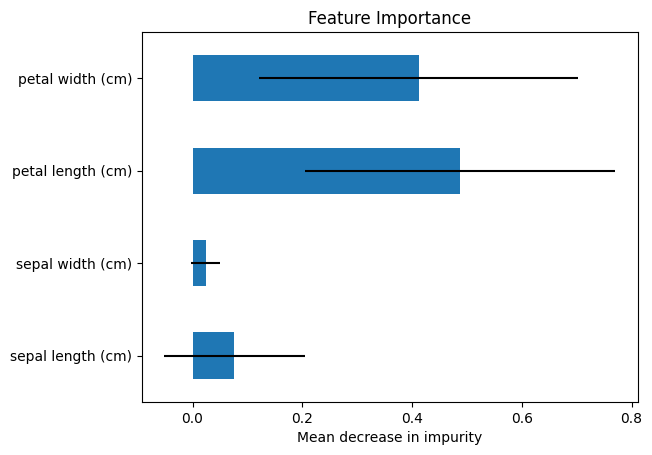

In [12]:
import matplotlib.pyplot as plt
importances.plot.barh(xerr=std)
plt.title("Feature Importance")
plt.xlabel("Mean decrease in impurity")

---

# Titanic: Disaster Survivability

Studiare i parametri che aiutano a comprendere cosa contribuisce alla sopravvivenza in un caso come quello del Titanic.


## Problem

Usare tecniche di analisi dei dati, grafici, ML, etc. per predire quali metriche contribuiscono alla sopravvivenza dei passeggeri.

### Data Dictionary

|Variable|Definition|Key|
|---|---|---|
|survival|Survival|0 = No, 1 = Yes|
|pclass|Ticket class|1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|Sex||
|Age|Age in years||
|sibsp|# of siblings / spouses aboard the Titanic||
|parch|# of parents / children aboard the Titanic||
|ticket|Ticket number||
|fare|Passenger fare||
|cabin|Cabin number||
|embarked|Port of Embarkation|C = Cherbourg, Q = Queenstown, S = Southampton|

### Notes

pclass: A proxy for socio-economic status (SES)
- 1st = Upper
- 2nd = Middle
- 3rd = Lower

age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

sibsp: The dataset defines family relations in this way...
- Sibling = brother, sister, stepbrother, stepsister
- Spouse = husband, wife (mistresses and fiancés were ignored)

parch: The dataset defines family relations in this way...
- Parent = mother, father
- Child = daughter, son, stepdaughter, stepson
- Some children travelled only with a nanny, therefore parch=0 for them.

## Dataset Exploration

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_titanic_train = pd.read_csv('data/titanic/train.csv')
df_titanic_test = pd.read_csv('data/titanic/test.csv')

In [14]:
df_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
df_titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [16]:
df_titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Ci sono 891 righe e 12 colonne nel dataset. 11 colonne sono features e 1 (Survived) è il target. 

Delle features, PassengerId non sarà rilevante per la predizione della sopravvivenza.

Abbiamo anche 3 colonne con valori nulli: Age, Cabin e Embarked.
Age potrebbe essere delicata da gestire, quindi lo farò dopo.
Cabin sarà da analizzare un po' più in dettaglio per capire se possiamo estrarre informazioni utili o se eliminare e basta.
Embarked è una feature categorica, quindi la gestirò in modo diverso. Avendo pochi valori nulli, comincerò a vedere se posso dedurre i valori mancanti.

### Embarked

In [17]:
df_titanic_train.groupby('Embarked').size()

Embarked
C    168
Q     77
S    644
dtype: int64

In [18]:
df_titanic_train[df_titanic_train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Potenzialmente, le persone che non hanno l'informazione su `Embarked` potrebbero essere state tutte in una stessa classe, con lo stesso ticket e/o lo stesso cabin, e quindi identificabili.

Verifichiamo se ci sono delle relazioni con altre righe.

In [19]:
df_titanic_train[df_titanic_train['Ticket'] == '113572']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [20]:
df_titanic_train[df_titanic_train['Cabin'] == 'B28']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [21]:
df_titanic_train[df_titanic_train['Fare'] == 80.0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Non ci sono relazioni - questi passeggeri però sembra siano saliti insieme.

Possiamo fare un'analisi più approfondita per capire quale sia il porto di imbarco più probabile

In [22]:
first_class = df_titanic_train[df_titanic_train['Pclass'] == 1]
first_class.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S


Vediamo se ci sono altri passeggeri con lo stesso cognome

In [23]:
#creo la colonna Surname
first_class.loc[:,'Surname'] = first_class['Name'].apply(lambda x: x.split(',')[0])

C:\Users\WilliamRussell\AppData\Local\Temp\ipykernel_31012\970860123.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_class.loc[:,'Surname'] = first_class['Name'].apply(lambda x: x.split(',')[0])


In [24]:
first_class[first_class['Surname'].isin(('Stone','Icard'))]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,Icard
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,Stone


In [25]:
#o nel resto dei dati? questa volta con un metodo più furbo che non aggiunge colonne
surname = df_titanic_train['Name'].apply(lambda x: x.split(',')[0])
df_titanic_train[surname.isin(('Stone','Icard'))]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Non ci sono altri passeggeri con lo stesso cognome

La soluzione più semplice è assegnare il porto di imbarco più frequente

In [26]:
df_titanic_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [27]:
df_titanic_train.fillna({'Embarked':df_titanic_train['Embarked'].value_counts().idxmax()}, inplace=True)
df_titanic_train[df_titanic_train['Ticket']=='113572']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,S
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,S


### Check Test Data

Controlliamo se ci sono valori nulli anche in test. I valori nulli in test saranno gestiti in modo simile a quelli in train, quindi dovremmo farlo in parallelo.

In [28]:
df_titanic_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In test non ci sono valori nulli in `Embarked`, ma ci sono valori nulli in `Fare`, `Cabin` e `Age`.

`Fare` lo riempiremo adesso, e gli altri li riempiremo con la stessa logica usata sul DataFrame "train".

### Fare

In [29]:
df_titanic_test[df_titanic_test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [30]:
# controlliamo se ci sono altri passeggeri con lo stesso Ticket
df_titanic_test[df_titanic_test['Ticket'] == '3701']

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [31]:
# non ci sono altri passeggeri con lo stesso Ticket.
# ci sono altre persone con lo stesso cognome?
surname = df_titanic_test['Name'].apply(lambda x: x.split(',')[0])
df_titanic_test[surname == 'Storey']

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [32]:
# non ci sono altre persone con lo stesso cognome
# la soluzione più semplice è assegnare il valore della tariffa più comune o la media delle tariffe per la classe
# raggruppiamo per classe e calcoliamo la media delle tariffe
df_titanic_test.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,107.0,94.280297,84.435858,0.0000,30.10,60.0000,134.5,512.3292
2,93.0,22.202104,13.991877,9.6875,13.00,15.7500,26.0,73.5000
3,217.0,12.459678,10.803698,3.1708,7.75,7.8958,14.4,69.5500


In [33]:
df_titanic_test['Fare'] = df_titanic_test['Fare'].groupby(df_titanic_test['Pclass'], group_keys=False).apply(lambda x: x.fillna(x.mean()))

In [34]:
# controlliamo di non aver alterato la media delle tariffe

df_titanic_test.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,107.0,94.280297,84.435858,0.0000,30.10,60.0000,134.500000,512.3292
2,93.0,22.202104,13.991877,9.6875,13.00,15.7500,26.000000,73.5000
3,218.0,12.459678,10.778775,3.1708,7.75,7.8958,14.327075,69.5500


### Cabin

Cabin ha molti valori nulli, quindi potrebbe essere una feature da eliminare. Tuttavia, potrebbe essere interessante vedere se possiamo estrarre informazioni utili da essa.

In [35]:
df_titanic_train.groupby(['Cabin']).size()

Cabin
A10    1
A14    1
A16    1
A19    1
A20    1
      ..
F33    3
F38    1
F4     2
G6     4
T      1
Length: 147, dtype: int64

In [36]:
df_titanic_train['Cabin'].sort_values().unique()

array(['A10', 'A14', 'A16', 'A19', 'A20', 'A23', 'A24', 'A26', 'A31',
       'A32', 'A34', 'A36', 'A5', 'A6', 'A7', 'B101', 'B102', 'B18',
       'B19', 'B20', 'B22', 'B28', 'B3', 'B30', 'B35', 'B37', 'B38',
       'B39', 'B4', 'B41', 'B42', 'B49', 'B5', 'B50', 'B51 B53 B55',
       'B57 B59 B63 B66', 'B58 B60', 'B69', 'B71', 'B73', 'B77', 'B78',
       'B79', 'B80', 'B82 B84', 'B86', 'B94', 'B96 B98', 'C101', 'C103',
       'C104', 'C106', 'C110', 'C111', 'C118', 'C123', 'C124', 'C125',
       'C126', 'C128', 'C148', 'C2', 'C22 C26', 'C23 C25 C27', 'C30',
       'C32', 'C45', 'C46', 'C47', 'C49', 'C50', 'C52', 'C54', 'C62 C64',
       'C65', 'C68', 'C7', 'C70', 'C78', 'C82', 'C83', 'C85', 'C86',
       'C87', 'C90', 'C91', 'C92', 'C93', 'C95', 'C99', 'D', 'D10 D12',
       'D11', 'D15', 'D17', 'D19', 'D20', 'D21', 'D26', 'D28', 'D30',
       'D33', 'D35', 'D36', 'D37', 'D45', 'D46', 'D47', 'D48', 'D49',
       'D50', 'D56', 'D6', 'D7', 'D9', 'E10', 'E101', 'E12', 'E121',
       'E17',

In [37]:
# la cabina è composta da una lettera e un numero (tranne in qualche caso)
# sarebbe interessante capire se la lettera della cabina è correlata con la classe
df_titanic_train['Cabin_letter'] = df_titanic_train['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
# Ho usato 'U' per indicare 'Unknown'
df_titanic_train.groupby(['Pclass', 'Cabin_letter']).size()

Pclass  Cabin_letter
1       A                15
        B                47
        C                59
        D                29
        E                25
        T                 1
        U                40
2       D                 4
        E                 4
        F                 8
        U               168
3       E                 3
        F                 5
        G                 4
        U               479
dtype: int64

In [38]:
# forse la lettera della cabina la potremmo dedurre da Ticket
# controlliamo se ci sono passeggeri con lo stesso Ticket tra U e le altre lettere
df_titanic_train[df_titanic_train['Cabin_letter'] != 'U']['Ticket'].isin(df_titanic_train[df_titanic_train['Cabin_letter'] == 'U']['Ticket']).sum()

np.int64(17)

In [39]:
known = df_titanic_train[~(df_titanic_train['Cabin_letter'] == 'U') & (df_titanic_train['Ticket'].isin(df_titanic_train[df_titanic_train['Cabin_letter'] == 'U']['Ticket']))]
known

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_letter
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C,F
269,270,1,1,"Bissette, Miss. Amelia",female,35.00,0,0,PC 17760,135.6333,C99,S,C
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,C
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,C
318,319,1,1,"Wick, Miss. Mary Natalie",female,31.00,0,2,36928,164.8667,C7,S,C
325,326,1,1,"Young, Miss. Marie Grice",female,36.00,0,0,PC 17760,135.6333,C32,C,C
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,C
544,545,0,1,"Douglas, Mr. Walter Donald",male,50.00,1,0,PC 17761,106.4250,C86,C,C
550,551,1,1,"Thayer, Mr. John Borland Jr",male,17.00,0,2,17421,110.8833,C70,C,C
581,582,1,1,"Thayer, Mrs. John Borland (Marian Longstreth M...",female,39.00,1,1,17421,110.8833,C68,C,C


In [40]:
unknown = df_titanic_train[(df_titanic_train['Cabin_letter'] == 'U') & (df_titanic_train['Ticket'].isin(df_titanic_train[df_titanic_train['Cabin_letter'] != 'U']['Ticket']))]
unknown

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_letter
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,U
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S,U
306,307,1,1,"Fleming, Miss. Margaret",female,NaN,0,0,17421,110.8833,NaN,C,U
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,NaN,C,U
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C,U
533,534,1,3,"Peter, Mrs. Catherine (Catherine Rizk)",female,NaN,0,2,2668,22.3583,NaN,C,U
537,538,1,1,"LeRoy, Miss. Bertha",female,30.0,0,0,PC 17761,106.4250,NaN,C,U
557,558,0,1,"Robbins, Mr. Victor",male,NaN,0,0,PC 17757,227.5250,NaN,C,U
708,709,1,1,"Cleaver, Miss. Alice",female,22.0,0,0,113781,151.5500,NaN,S,U
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,NaN,S,U


Possiamo associare la lettera della cabina a questi passeggeri per cui abbiamo trovato una corrispondenza sul Ticket

In [41]:
# usiamo known come filtro per aggiornare i valori di Cabin_letter in df_titanic_train
# prima controlliamo la selezione dei dati
df_titanic_train.loc[(df_titanic_train['Cabin_letter'] == 'U') & (df_titanic_train['Ticket'].isin(known['Ticket'])), 'Cabin_letter']

258    U
290    U
306    U
373    U
380    U
533    U
537    U
557    U
708    U
841    U
856    U
Name: Cabin_letter, dtype: object

In [42]:
# ora recuperiamo i valori univoci di Ticket da known, con la lettera della cabina associata
known.drop_duplicates(subset=['Ticket']).set_index('Ticket')['Cabin_letter']

Ticket
2668           F
PC 17760       C
113781         C
36928          C
PC 17761       C
17421          C
PC 17755       B
PC 17757       C
19877          C
S.O./P.P. 3    E
Name: Cabin_letter, dtype: object

In [43]:
# mappiamo i valori di Cabin_letter, unificando i pezzi di codice precedenti
df_titanic_train.loc[(df_titanic_train['Cabin_letter'] == 'U') & (df_titanic_train['Ticket'].isin(known['Ticket'])), 'Ticket'].map(known.drop_duplicates(subset=['Ticket']).set_index('Ticket')['Cabin_letter'])

258    B
290    C
306    C
373    C
380    C
533    F
537    C
557    C
708    C
841    E
856    C
Name: Ticket, dtype: object

In [44]:
df_titanic_train[(df_titanic_train['Cabin_letter'] == 'U')].shape

(687, 13)

In [45]:
# unifichiamo le logiche di assegnazione e mappatura
df_titanic_train.loc[(df_titanic_train['Cabin_letter'] == 'U') & (df_titanic_train['Ticket'].isin(known['Ticket'])), 'Cabin_letter'] = df_titanic_train.loc[(df_titanic_train['Cabin_letter'] == 'U') & (df_titanic_train['Ticket'].isin(known['Ticket'])), 'Ticket'].map(known.drop_duplicates(subset=['Ticket']).set_index('Ticket')['Cabin_letter'])

In [46]:
df_titanic_train[(df_titanic_train['Cabin_letter'] == 'U')].shape

(676, 13)

La scelta della lettera U per i restanti valori nulli è arbitraria, ma è una scelta utile per rappresentare valori ignoti. Per così Pochi valori non importava, ma è un buon esercizio per altre situazioni.

Dobbiamo sistemare anche i dati di Test, ma lo faremo alla fine con un metodo unificato per entrambi i dataset e tutte le logiche esplorate. 


In [47]:
df_titanic_test['Cabin_letter'] = df_titanic_test['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')

# e cancelliamo la colonna Cabin
df_titanic_train.drop('Cabin', axis=1, inplace=True)
df_titanic_test.drop('Cabin', axis=1, inplace=True)

df_titanic_train


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_letter
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,U
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,U
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,U
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,U
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,U
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,C


### Age

Age è possibilmente una feature importante, quindi dobbiamo gestire i valori nulli con cura.

Iniziamo con qualche analisi per capire come gestire i valori nulli.

In [48]:
age_nulls = df_titanic_train[df_titanic_train['Age'].isnull()]
age_nulls.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_letter
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q,U
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,S,U
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,C,U
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,C,U
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,Q,U
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,S,U
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,C,B
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,Q,U
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,C,U
42,43,0,3,"Kraeff, Mr. Theodor",male,NaN,0,0,349253,7.8958,C,U


In [49]:
age_nulls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177 entries, 5 to 888
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   177 non-null    int64  
 1   Survived      177 non-null    int64  
 2   Pclass        177 non-null    int64  
 3   Name          177 non-null    object 
 4   Sex           177 non-null    object 
 5   Age           0 non-null      float64
 6   SibSp         177 non-null    int64  
 7   Parch         177 non-null    int64  
 8   Ticket        177 non-null    object 
 9   Fare          177 non-null    float64
 10  Embarked      177 non-null    object 
 11  Cabin_letter  177 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.0+ KB


Ci sono 177 valori nulli. Vediamo se possiamo inferire l'età in base ad altre features. Siamo avvantaggiati dal fatto che ci sono altre features che potrebbero aiutarci a inferire l'età e sono tutte riempite.

In [50]:
df_titanic_train.groupby(['Survived', 'Pclass', 'Sex'])['Age'].describe()

count       mean        std    min    25%   50%  \
Survived Pclass Sex                                                       
0        1      female    3.0  25.666667  24.006943   2.00  13.50  25.0   
                male     61.0  44.581967  14.457749  18.00  33.00  45.5   
         2      female    6.0  36.000000  12.915107  24.00  26.25  32.5   
                male     84.0  33.369048  12.158125  16.00  24.75  30.5   
         3      female   55.0  23.818182  12.833465   2.00  15.25  22.0   
                male    215.0  27.255814  12.135707   1.00  20.00  25.0   
1        1      female   82.0  34.939024  13.223014  14.00  23.25  35.0   
                male     40.0  36.248000  14.936744   0.92  27.00  36.0   
         2      female   68.0  28.080882  12.764693   2.00  21.75  28.0   
                male     15.0  16.022000  19.547122   0.67   1.00   3.0   
         3      female   47.0  19.329787  12.303246   0.75  13.50  19.0   
                male     38.0  22.274211  11.555786   0.42  16.50  25.0   

                          75%   max  
Survived Pclass Sex                  
0        1      female  37.50  50.0  
                male    56.00  71.0  
         2      female  42.50  57.0  
                male    39.00  70.0  
         3      female  31.00  48.0  
                male    34.00  74.0  
1        1      female  44.00  63.0  
                male    48.00  80.0  
         2      female  35.25  55.0  
                male    31.50  62.0  
         3      female  26.50  63.0  
                male    29.75  45.0

Le features più utili e facilili da usare sono Survived, Pclass, e Sex. Riempiremo i valori nulli in Age in base alla media del raggruppamento. Sceglieremo un valore random tra la media e la deviazione standard.

In [51]:
def fill_age(group):
    return group.fillna(np.random.randint(group.mean()-group.std(), group.mean()+group.std()))

def fill_age_df(df):
    # riempiamo i valori mancanti di Age con la media della classe e del sesso. 
    # non usiamo Survived anche se potrebbe essere correlato - il dataset di test non ha la colonna Survived
    df['Age'] = df['Age'].groupby([df['Pclass'], df['Sex']], group_keys=False).apply(fill_age)

fill_age_df(df_titanic_train)

df_titanic_train.groupby(['Survived', 'Pclass', 'Sex'])['Age'].describe()

count       mean        std    min    25%   50%  \
Survived Pclass Sex                                                       
0        1      female    3.0  25.666667  24.006943   2.00  13.50  25.0   
                male     77.0  46.331169  13.298103  18.00  37.00  50.0   
         2      female    6.0  36.000000  12.915107  24.00  26.25  32.5   
                male     91.0  33.263736  11.681500  16.00  25.00  32.0   
         3      female   72.0  20.555556  12.656501   2.00  10.00  18.0   
                male    300.0  28.033333  10.341278   1.00  22.00  30.0   
1        1      female   91.0  35.637363  12.722261  14.00  24.00  36.0   
                male     45.0  38.109333  15.036613   0.92  28.00  36.0   
         2      female   70.0  27.935714  12.607199   2.00  22.00  28.0   
                male     17.0  17.901765  19.039076   0.67   1.00   8.0   
         3      female   72.0  16.090278  10.866370   0.75  10.00  11.5   
                male     47.0  23.753617  10.809781   0.42  19.50  27.0   

                          75%   max  
Survived Pclass Sex                  
0        1      female  37.50  50.0  
                male    53.00  71.0  
         2      female  42.50  57.0  
                male    36.75  70.0  
         3      female  29.25  48.0  
                male    30.00  74.0  
1        1      female  42.50  63.0  
                male    49.00  80.0  
         2      female  34.75  55.0  
                male    32.00  62.0  
         3      female  22.25  63.0  
                male    30.00  45.0

#### Distribuzione di Age

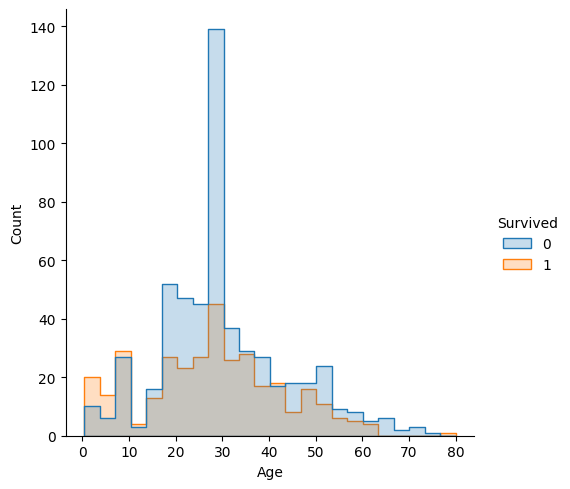

In [52]:
sns.displot(data=df_titanic_train, x='Age', hue='Survived', element='step')

#### Categorie di Age

Anziché usare le età esatte, per un modello migliore forse sarebbe più facile raggruppare le età in fasce di età. Questo dovrebbe permettere al modello di generalizzare meglio.

Sarà utile anche per noi, dato che ci sono molte età diverse e potrebbe essere difficile trovare un pattern o trarre conclusioni.

In [53]:
# potremmo creare delle fasce di età
bins = [0, 12, 18, 30, 50, 65, 100]
age_group_labels = ['child', 'teenager', 'young adult', 'adult', 'senior', 'old']
df_titanic_train['Age_group'] = pd.cut(df_titanic_train['Age'], bins, labels=age_group_labels)
df_titanic_train.drop('Age', axis=1, inplace=True)

df_titanic_train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked,Cabin_letter,Age_group
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891,891.000000,891,891,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,681,NaN,3,9,6
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,347082,NaN,S,U,young adult
freq,NaN,NaN,NaN,1,577,NaN,NaN,7,NaN,646,676,366
mean,446.000000,0.383838,2.308642,NaN,NaN,0.523008,0.381594,NaN,32.204208,NaN,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,1.102743,0.806057,NaN,49.693429,NaN,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,0.000000,0.000000,NaN,7.910400,NaN,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,1.000000,0.000000,NaN,31.000000,NaN,NaN,NaN


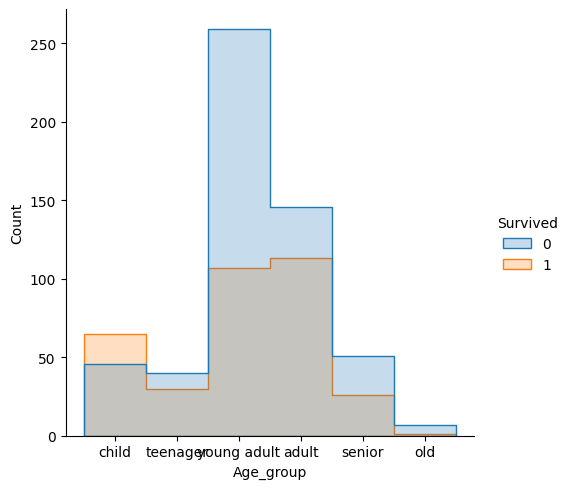

In [54]:
sns.displot(data=df_titanic_train, x='Age_group', hue='Survived', element='step')

### Altre Features

Per le altre features, dobbiamo capire se hanno senso per il nostro modello. Faremo delle analisi per capire se sono rilevanti o meno, e se lo sono, se è opportuno fare delle trasformazioni.

In [55]:
df_titanic_train.drop('PassengerId', axis=1, inplace=True) # intanto questa: non ha senso come feature

In [56]:
# quelle categoriche le trasformiamo in numeriche

def extract_map(df_column):
    mapping = dict(enumerate(df_column.unique()))
    # transformare il dict così che valori diventano chiavi e viceversa
    return {v: k for k,v in mapping.items()}

In [57]:
map_sexes = extract_map(df_titanic_train['Sex'])
map_sexes

{'male': 0, 'female': 1}

In [58]:
map_port = extract_map(df_titanic_train['Embarked'])
map_port

{'S': 0, 'C': 1, 'Q': 2}

In [59]:
map_age_group = extract_map(df_titanic_train['Age_group'])
map_age_group

{'young adult': 0,
 'adult': 1,
 'senior': 2,
 'child': 3,
 'teenager': 4,
 'old': 5}

In [60]:
df_titanic_train['Sex'] = df_titanic_train['Sex'].map(map_sexes)
df_titanic_train['Embarked'] = df_titanic_train['Embarked'].map(map_port)
df_titanic_train['Age_group'] = df_titanic_train['Age_group'].map(map_age_group)


In [61]:
map_deck = extract_map(df_titanic_train['Cabin_letter'])
map_deck

{'U': 0, 'C': 1, 'E': 2, 'G': 3, 'D': 4, 'A': 5, 'B': 6, 'F': 7, 'T': 8}

In [62]:
df_titanic_train['Deck'] = df_titanic_train['Cabin_letter'].map(map_deck)
df_titanic_train.drop('Cabin_letter', axis=1, inplace=True)

In [63]:
# Ticket non ha senso come feature dopo le correzioni fatte
df_titanic_train.drop('Ticket', axis=1, inplace=True)

In [64]:
# Name non l'abbiamo analizzato. Potrebbe essere interessante estrarre il titolo
def get_title(name):
    return name.split(',')[1].split('.')[0].strip()

df_titanic_train['Title'] = df_titanic_train['Name'].apply(get_title)
df_titanic_train['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer'], dtype=object)

In [65]:
# uniformiamo i titoli
# Mlle e Ms sono titoli simili a Miss
# Mme è simile a Mrs
# Mr, Mrs, Miss, Master sono titoli comuni
# gli altri titoli verranno raggruppati in 'other'
def convert_title(title):
    if title in ['Mlle', 'Ms']:
        return 'Miss'
    elif title == 'Mme':
        return 'Mrs'
    elif title in ['Mr', 'Mrs', 'Miss', 'Master']:
        return title
    else:
        return 'Other'
df_titanic_train['Title'] = df_titanic_train['Title'].apply(convert_title)

In [66]:
map_titles = extract_map(df_titanic_train['Title'])
map_titles

{'Mr': 0, 'Mrs': 1, 'Miss': 2, 'Master': 3, 'Other': 4}

In [67]:
df_titanic_train['Title'] = df_titanic_train['Title'].map(map_titles)
df_titanic_train.drop('Name', axis=1, inplace=True)

df_titanic_train.describe(include='all')

,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked,Age_group,Deck,Title
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.0,891.000000,891.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,366.0,NaN,NaN
mean,0.383838,2.308642,0.352413,0.523008,0.381594,32.204208,0.361392,NaN,0.837262,0.794613
std,0.486592,0.836071,0.477990,1.102743,0.806057,49.693429,0.635673,NaN,1.833338,1.076519
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,7.910400,0.000000,NaN,0.000000,0.000000
50%,0.000000,3.000000,0.000000,0.000000,0.000000,14.454200,0.000000,NaN,0.000000,0.000000
75%,1.000000,3.000000,1.000000,1.000000,0.000000,31.000000,1.000000,NaN,0.000000,2.000000


### Check visivo

Facciamo un plot per iniziare a vedere le correlazioni tra le variabili

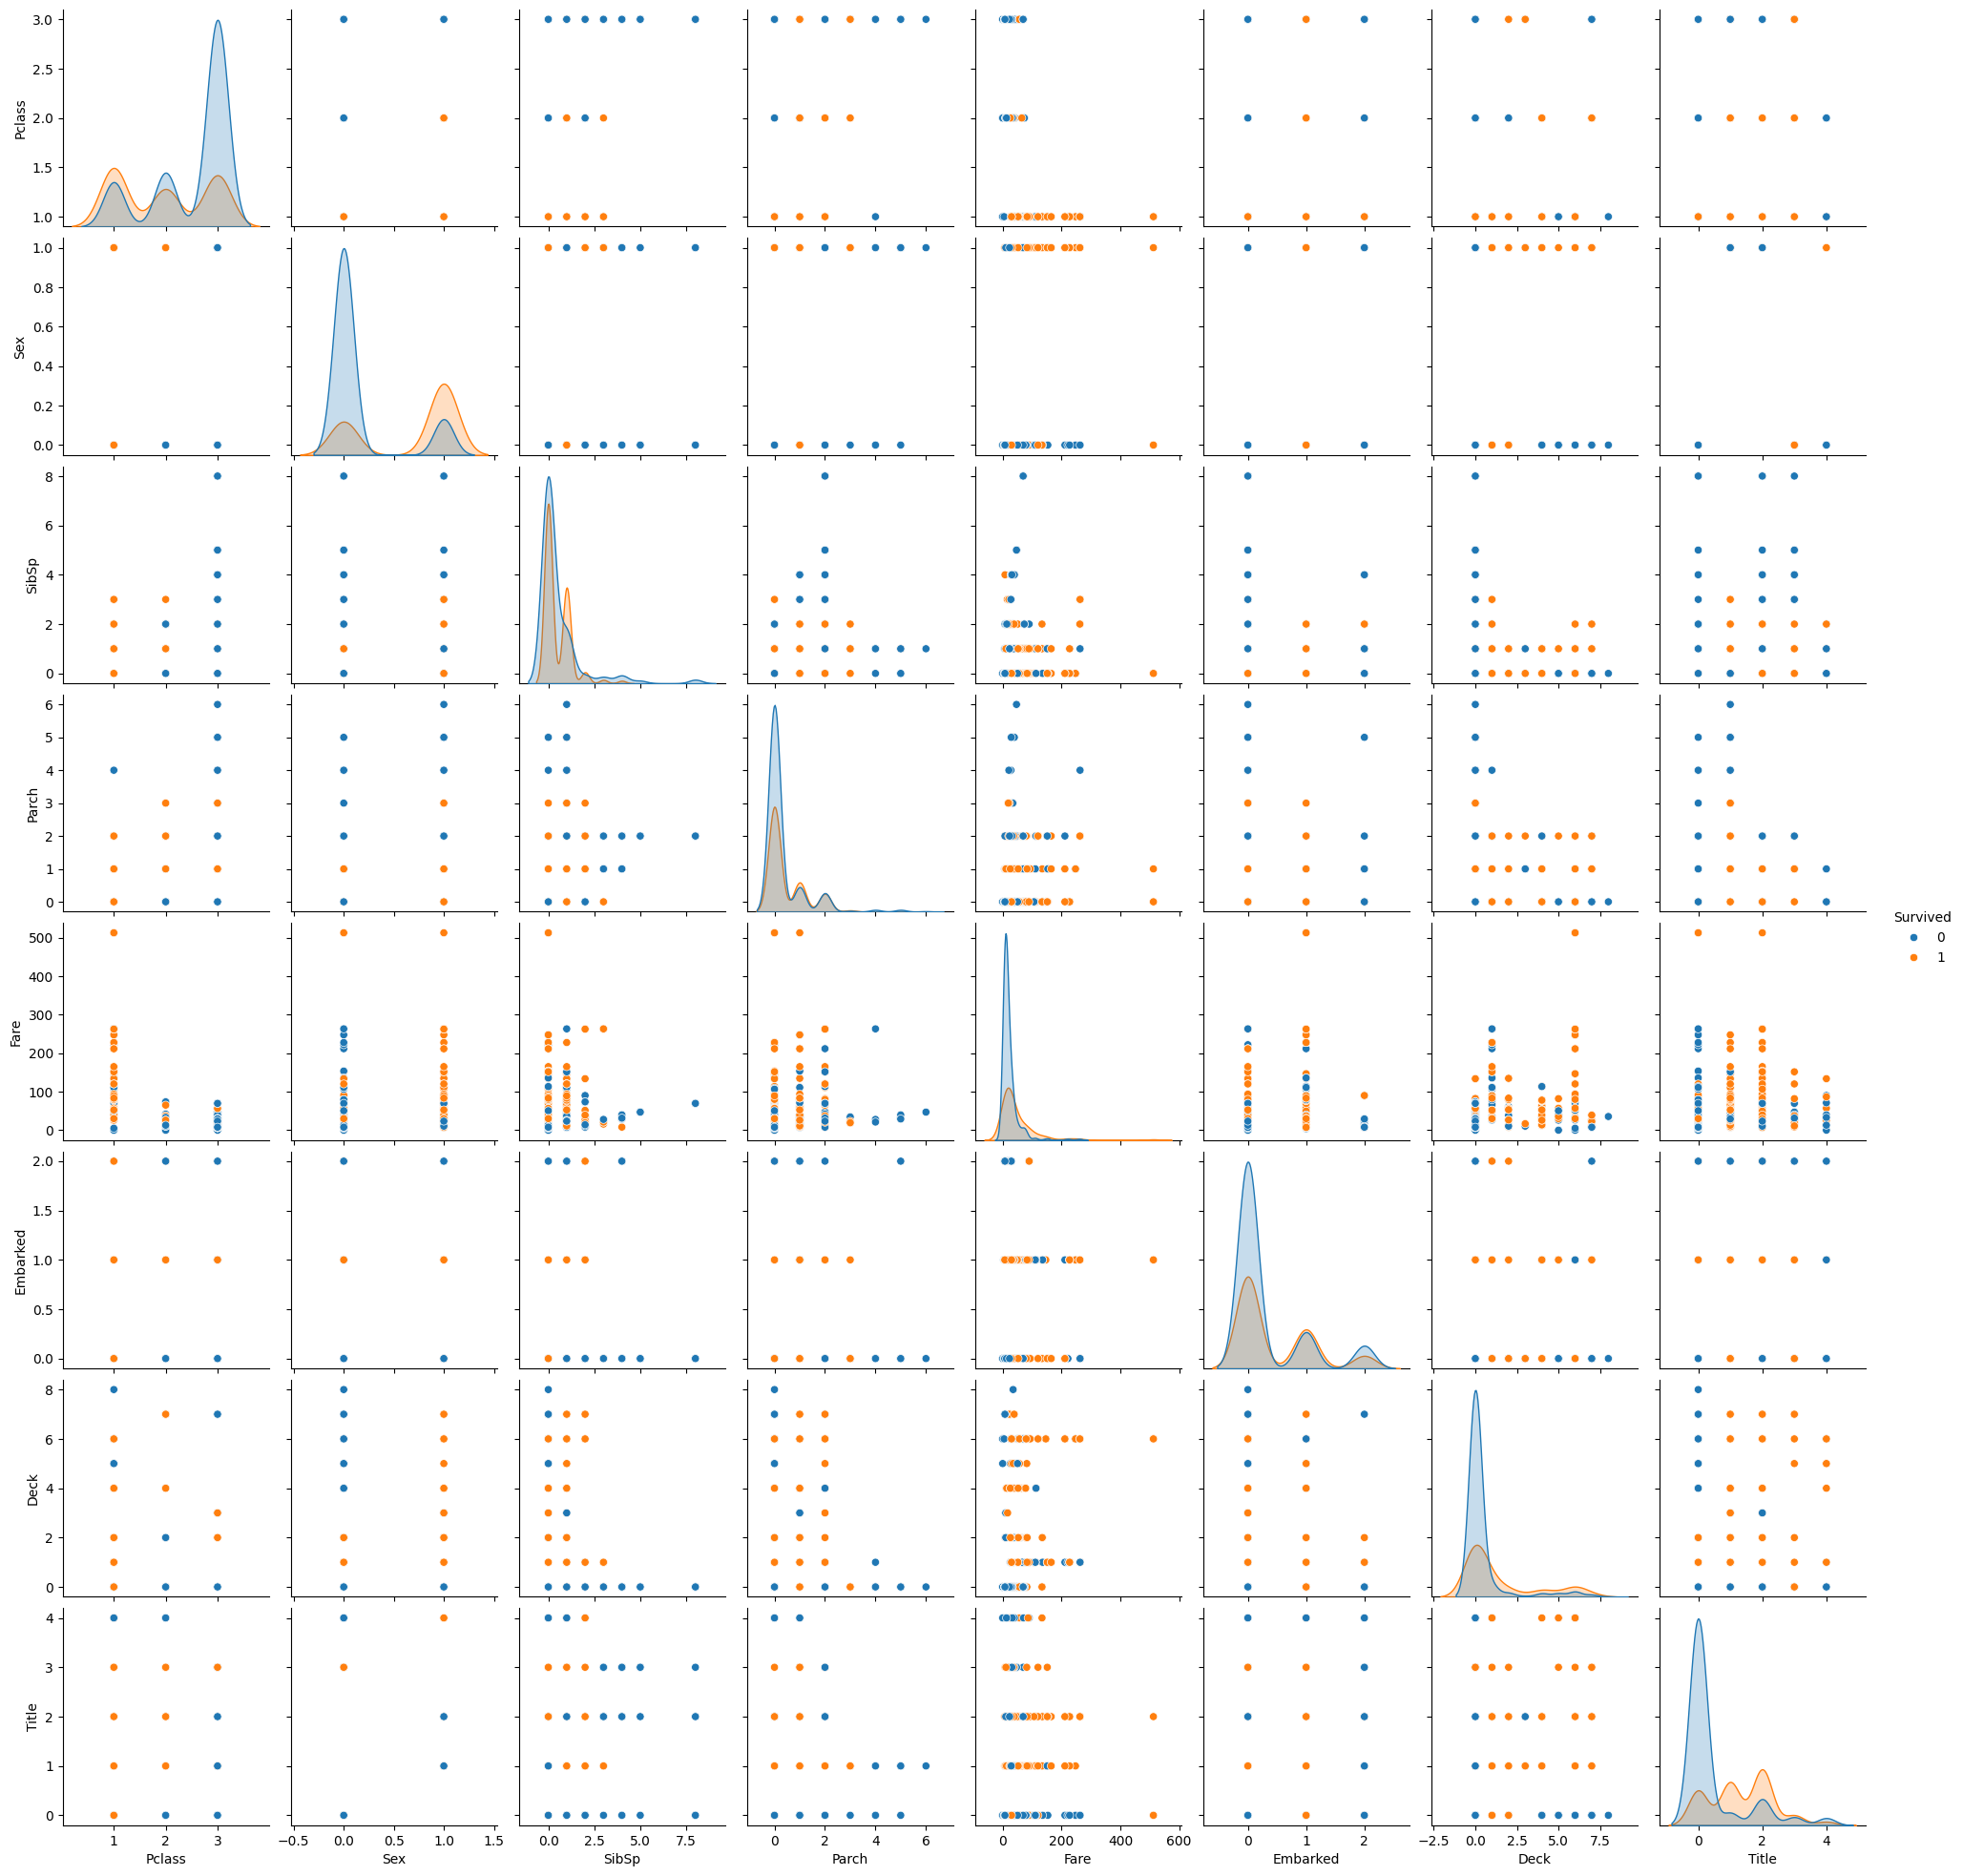

In [68]:
sns.pairplot(df_titanic_train, hue='Survived')

### Logiche Unificate

In [69]:
def fill_with_most_frequent(df_titanic:pd.DataFrame, col:str):
    df_titanic.fillna({col:df_titanic[col].value_counts().idxmax()}, inplace=True)
    
def fill_with_mean(df_titanic:pd.DataFrame, col:str):
    df_titanic.fillna({col:df_titanic[col].mean()}, inplace=True)

def fill_by_class_with_mean(df_titanic:pd.DataFrame, col:str):
    df_titanic[col] = df_titanic[col].groupby(df_titanic['Pclass'], group_keys=False).apply(lambda x: x.fillna(x.mean()))

def extract_deck_from_cabin_letter(df_titanic:pd.DataFrame):
    df_titanic['Deck'] = df_titanic['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')

def retrieve_deck_by_ticket(df_titanic:pd.DataFrame):
    known = df_titanic[~(df_titanic['Deck'] == 'U') & (df_titanic['Ticket'].isin(df_titanic[df_titanic['Deck'] == 'U']['Ticket']))]
    map_letters = known.drop_duplicates(subset=['Ticket']).set_index('Ticket')['Deck']
    filter = (df_titanic['Deck'] == 'U') & (df_titanic['Ticket'].isin(known['Ticket']))
    df_titanic.loc[filter, 'Deck'] = df_titanic.loc[filter, 'Ticket'].map(map_letters)

def group_age_into_bins(df_titanic:pd.DataFrame):
    bins = [0, 12, 18, 30, 50, 65, 100]
    age_group_labels = ['child', 'teenager', 'young adult', 'adult', 'senior', 'old']
    df_titanic['Age_group'] = pd.cut(df_titanic['Age'], bins, labels=age_group_labels)

def extract_title_from_name(df_titanic:pd.DataFrame):
    title = df_titanic['Name'].apply(get_title)
    df_titanic['Title'] = title.apply(convert_title)

def map_categorical_column(df_titanic:pd.DataFrame, col:str):
    map_col = extract_map(df_titanic[col])
    df_titanic[col] = df_titanic[col].map(map_col)
    
def map_categorical_columns(df_titanic:pd.DataFrame):
    map_categorical_column(df_titanic, 'Embarked')
    map_categorical_column(df_titanic, 'Age_group')
    map_categorical_column(df_titanic, 'Deck')
    map_categorical_column(df_titanic, 'Title')
    map_categorical_column(df_titanic, 'Sex')

def drop_columns(df_titanic:pd.DataFrame, cols:list):
    df_titanic.drop(cols, axis=1, inplace=True)

def apply_transformations(df_titanic:pd.DataFrame):
    fill_with_most_frequent(df_titanic, 'Embarked')
    fill_by_class_with_mean(df_titanic, 'Fare')
    fill_age_df(df_titanic)
    group_age_into_bins(df_titanic)
    extract_deck_from_cabin_letter(df_titanic)
    retrieve_deck_by_ticket(df_titanic)
    extract_title_from_name(df_titanic)
    map_categorical_columns(df_titanic)
    drop_columns(df_titanic, ['PassengerId', 'Name', 'Age', 'Ticket', 'Cabin'])

## ML

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
# ricominciamo da capo con i due dataframe
df_titanic_train = pd.read_csv('data/titanic/train.csv')
df_titanic_test = pd.read_csv('data/titanic/test.csv')

In [72]:
# creiamo i dataframe di train e test

X_train = df_titanic_train.drop("Survived", axis=1)
y_train = df_titanic_train["Survived"]


apply_transformations(X_train)

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

### Valutazione modelli

In [73]:
scoring = []

In [74]:
class Score:
    def __init__(self, model_name, accuracy):
        self.model_name = model_name
        self.accuracy = accuracy

    def to_dict(self):
        return {'Model': self.model_name, 'Accuracy': self.accuracy}

In [75]:
def add_score(model, accuracy):
    scoring.append(Score(model.__class__.__name__, accuracy))

def fit_score(model):
    model.fit(X_train, y_train)
    return round(model.score(X_test, y_test) * 100, 3)

def evaluate_model(model):
    accuracy = fit_score(model)
    add_score(model, accuracy)
    print(f'Model: {model.__class__.__name__}, Accuracy: {accuracy}%')
    return accuracy

In [76]:
# Stochastic Gradient Descent
from sklearn.linear_model import SGDClassifier

# evaluate_model(SGDClassifier(max_iter=5, tol=None)) # Accuracy al 58% circa
evaluate_model(SGDClassifier(max_iter=500, tol=None))

Model: SGDClassifier, Accuracy: 75.978%


75.978

In [77]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

evaluate_model(LogisticRegression(max_iter=1000))

Model: LogisticRegression, Accuracy: 77.095%


77.095

In [78]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

evaluate_model(RandomForestClassifier(n_estimators=100))

Model: RandomForestClassifier, Accuracy: 83.24%


83.24

In [79]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

evaluate_model(KNeighborsClassifier(n_neighbors=3))

Model: KNeighborsClassifier, Accuracy: 78.212%


78.212

In [80]:
# Support Vector Machines
from sklearn.svm import SVC

evaluate_model(SVC())

Model: SVC, Accuracy: 66.48%


66.48

In [81]:
# Linear SVC
from sklearn.svm import LinearSVC

evaluate_model(LinearSVC())

Model: LinearSVC, Accuracy: 79.33%


79.33

In [82]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

evaluate_model(GaussianNB())


Model: GaussianNB, Accuracy: 77.095%


77.095

In [83]:
# Perceptron
from sklearn.linear_model import Perceptron

evaluate_model(Perceptron(max_iter=500))

Model: Perceptron, Accuracy: 58.101%


58.101

In [84]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

evaluate_model(DecisionTreeClassifier())

Model: DecisionTreeClassifier, Accuracy: 79.888%


79.888

In [85]:
scores_df = pd.DataFrame([score.to_dict() for score in scoring])
scores_df = scores_df.sort_values(by='Accuracy', ascending=False)
scores_df

,Model,Accuracy
2,RandomForestClassifier,83.240
8,DecisionTreeClassifier,79.888
5,LinearSVC,79.330
3,KNeighborsClassifier,78.212
6,GaussianNB,77.095
1,LogisticRegression,77.095
0,SGDClassifier,75.978
4,SVC,66.480
7,Perceptron,58.101


Da questi punteggi, possiamo vedere che il modello migliore è il Random Forest Classifier seguito da Decision Tree Classifier e KNeighborsClassifier.


### Cross Validation

In [86]:
from sklearn.metrics import get_scorer_names

get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [87]:
from sklearn.model_selection import cross_val_score, cross_validate
def fit_cvscore(model):
    return cross_val_score(model, X_train, y_train, cv=5)

def fit_cvscores(model):
    return cross_validate(model, X_train, y_train, cv=5, scoring=('accuracy', 'precision', 'recall', 'f1', 'roc_auc'))

In [88]:
cvresults = []

class CVResult:
    def __init__(self, model_name, score_mean, score_std):
        self.model_name = model_name
        self.score_mean = score_mean
        self.score_std = score_std

    def to_dict(self):
        return {'Model': self.model_name, 'Score_mean': self.score_mean, 'Score_std': self.score_std}

In [89]:
def add_cvresult(model):
    score = fit_cvscore(model)
    cvresults.append(CVResult(model.__class__.__name__, score.mean(), score.std()))

In [90]:
cvscores = []

class CVScore:
    def __init__(self, model_name, accuracy, precision, recall, f1, roc_auc):
        self.model_name = model_name
        self.accuracy = accuracy
        self.precision = precision
        self.recall = recall
        self.f1 = f1
        self.roc_auc = roc_auc

    def to_dict(self):
        return {'Model': self.model_name, 'Accuracy': self.accuracy, 'Precision': self.precision, 'Recall': self.recall, 'F1': self.f1, 'ROC_AUC': self.roc_auc}


In [91]:
def add_cvscore(model):
    scores = fit_cvscores(model)
    cvscores.append(
        CVScore(
            model.__class__.__name__,
            scores['test_accuracy'].mean(),
            scores['test_precision'].mean(),
            scores['test_recall'].mean(),
            scores['test_f1'].mean(),
            scores['test_roc_auc'].mean()
        )
    )

In [92]:
def get_models_list():
    return [
        SGDClassifier(max_iter=500, tol=None),
        LogisticRegression(max_iter=1000),
        RandomForestClassifier(n_estimators=100),
        KNeighborsClassifier(n_neighbors=3),
        SVC(),
        LinearSVC(),
        GaussianNB(),
        Perceptron(max_iter=500),
        DecisionTreeClassifier()
    ]

In [93]:
for model in get_models_list():
    add_cvresult(model)

In [94]:
for model in get_models_list():
    add_cvscore(model)
    

c:\Users\WilliamRussell\github\Course_ITS-BigData24-26_Anno2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [95]:
results_df = pd.DataFrame([cvresult.to_dict() for cvresult in cvresults])
results_df = results_df.sort_values(by='Score_mean', ascending=False)
results_df

,Model,Score_mean,Score_std
2,RandomForestClassifier,0.813237,0.011668
5,LinearSVC,0.796307,0.028769
1,LogisticRegression,0.787876,0.030609
8,DecisionTreeClassifier,0.775298,0.010459
6,GaussianNB,0.770994,0.033040
3,KNeighborsClassifier,0.761273,0.048657
0,SGDClassifier,0.745720,0.033857
7,Perceptron,0.707870,0.055345
4,SVC,0.674106,0.017882


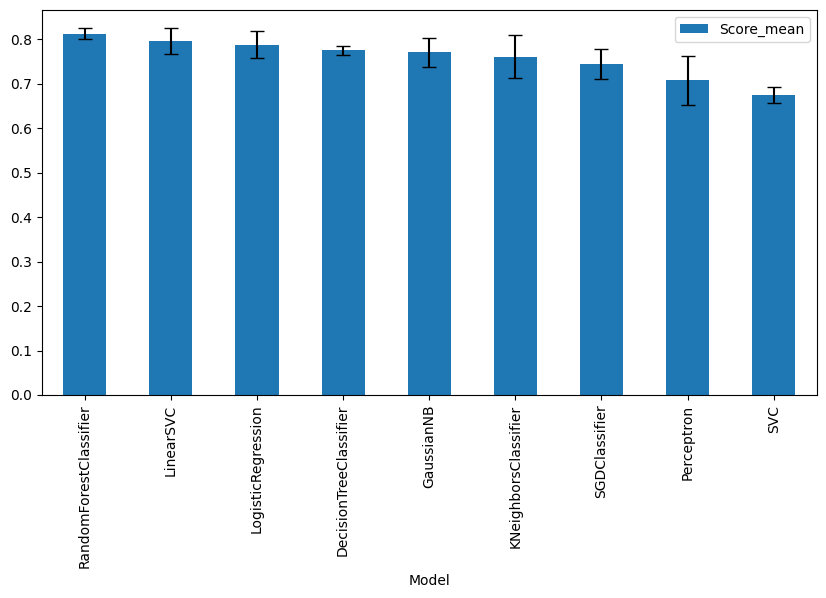

In [96]:
ax = results_df.plot.bar(x='Model', y='Score_mean', figsize=(10, 5), yerr='Score_std', capsize=5)
ax.tick_params(axis='x', rotation=90)

In [97]:
scores_df = pd.DataFrame([cvscore.to_dict() for cvscore in cvscores])
scores_df = scores_df.sort_values(by='Accuracy', ascending=False)
scores_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,RandomForestClassifier,0.813228,0.774634,0.712648,0.741856,0.861466
5,LinearSVC,0.796307,0.744807,0.697275,0.718727,0.835971
1,LogisticRegression,0.787876,0.737427,0.674843,0.703652,0.834794
8,DecisionTreeClassifier,0.778105,0.714752,0.690147,0.701105,0.759456
6,GaussianNB,0.770994,0.685931,0.719846,0.702356,0.811375
3,KNeighborsClassifier,0.761273,0.695622,0.641370,0.663769,0.788327
7,Perceptron,0.707870,0.552287,0.439902,0.464938,0.716499
4,SVC,0.674106,0.713322,0.238784,0.353929,0.753754
0,SGDClassifier,0.665803,0.596742,0.405730,0.411904,0.644408


In [98]:
# plot scores
def get_short(model_name):
    # get capital letters
    return ''.join([c for c in model_name if c.isupper()])

scores_df['short_model'] = scores_df['Model'].apply(get_short)

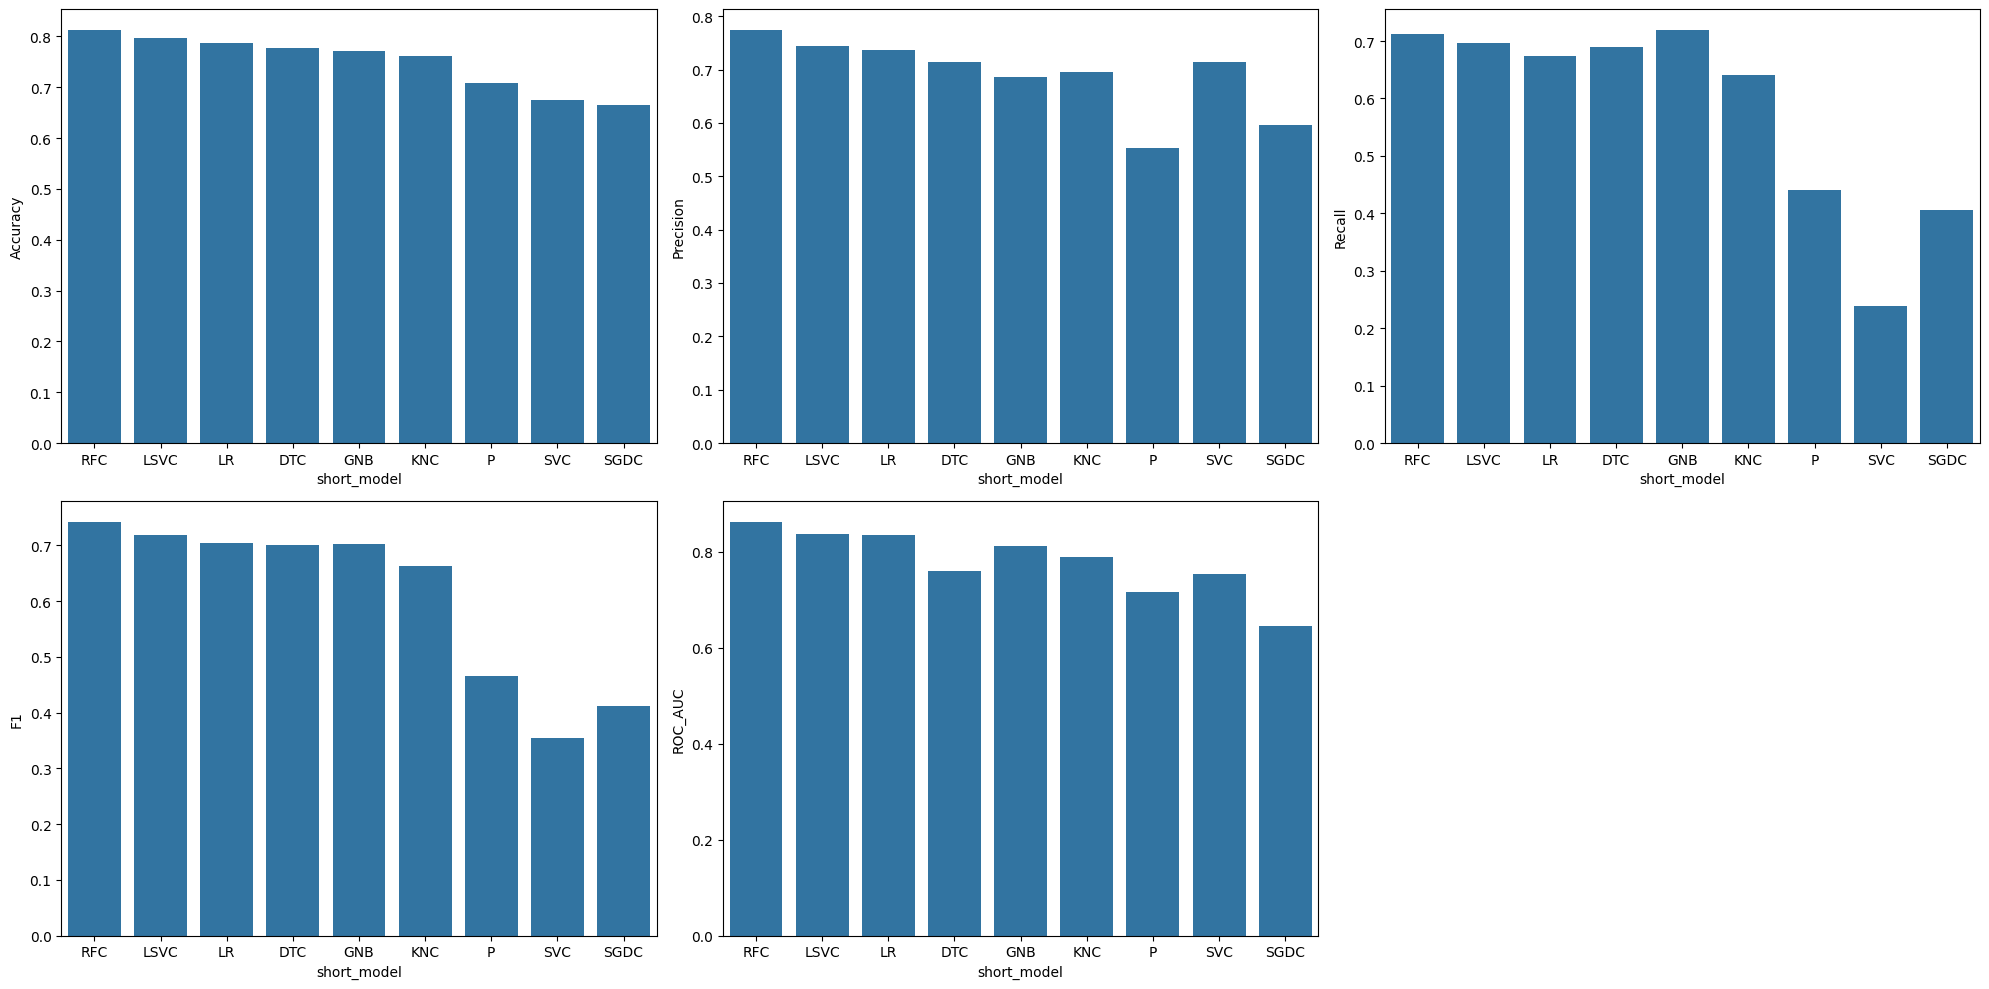

In [99]:
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
sns.barplot(data=scores_df, x='short_model', y='Accuracy', ax=ax[0, 0])
sns.barplot(data=scores_df, x='short_model', y='Precision', ax=ax[0, 1])
sns.barplot(data=scores_df, x='short_model', y='Recall', ax=ax[0, 2])
sns.barplot(data=scores_df, x='short_model', y='F1', ax=ax[1, 0])
sns.barplot(data=scores_df, x='short_model', y='ROC_AUC', ax=ax[1, 1])

# remove the empty subplot
fig.delaxes(ax[1, 2])

fig.tight_layout()

Random Forest risulta un buon modello per questo problema, come dimostrato in questi grafici. I punteggi ottenuti sono i più alti tra i modelli testati in tutte le metriche usate.

Se dovessimo guardare solo i punteggi di Accuracy da scores_df, Random Forest e Linear SVC sembrano i migliori modelli. Tuttavia, se guardiamo anche le altre metriche, Random Forest è il migliore.

### Feature Importances

In [100]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
importances = pd.Series(random_forest.feature_importances_, index=random_forest.feature_names_in_)
importances = importances.sort_values(ascending=False)
importances

Fare         0.278062
Title        0.191480
Sex          0.161444
Pclass       0.081944
Age_group    0.081709
Deck         0.071713
SibSp        0.061454
Embarked     0.036133
Parch        0.036061
dtype: float64

Guardando le feature importances, possiamo vedere che le features più importanti sono Fare e Title. Questo è interessante, dato che non avevamo considerato Title come feature importante. 

Al terzo posto c'è Sex, che era una feature che avevamo considerato importante. 

Non risultano molto importanti Age_group, Deck e Pclass che sembravano più rilevanti. Questo potrebbe essere dovuto al fatto che Age_group e Deck sono state trasformate e potrebbero aver perso informazioni importanti, soprattutto Age_group, mentre Pclass potrebbe essere stata influenzata o oscurata da altre features.

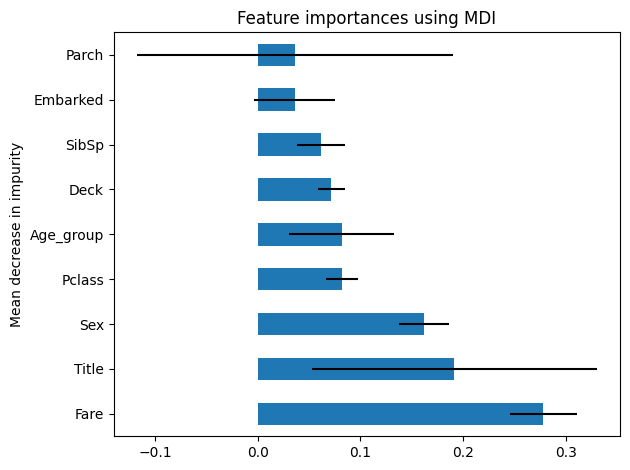

In [103]:
std = np.std([tree.feature_importances_ for tree in random_forest.estimators_], axis=0)

fig, ax = plt.subplots()
importances.plot.barh(xerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

## Output dei Risultati

In [104]:
X_val  = df_titanic_test.copy()

apply_transformations(X_val)
y_pred = random_forest.predict(X_val)

submission = pd.DataFrame({
    "PassengerId": df_titanic_test["PassengerId"],
    "Survived": y_pred
})
submission.to_csv('data/titanic/submission.csv', index=False)
submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [105]:
# get survival rate
submission['Survived'].value_counts(normalize=True)

Survived
0    0.610048
1    0.389952
Name: proportion, dtype: float64

In [106]:
# compare with training set
df_titanic_train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Migliorie?

In [107]:
def apply_transformations_2(df_titanic:pd.DataFrame):
    fill_with_most_frequent(df_titanic, 'Embarked')
    fill_by_class_with_mean(df_titanic, 'Fare')
    fill_age_df(df_titanic)
    group_age_into_bins(df_titanic)
    extract_deck_from_cabin_letter(df_titanic)
    retrieve_deck_by_ticket(df_titanic)
    extract_title_from_name(df_titanic)
    map_categorical_columns(df_titanic)
    drop_columns(df_titanic, ['PassengerId', 'Name', 'Embarked', 'Ticket', 'Cabin']) # keeping Age, removing Embarked, Parch (below 60% importance)

In [108]:
X_train = df_titanic_train.drop("Survived", axis=1).copy()
y_train = df_titanic_train["Survived"].copy()
X_test  = df_titanic_test.copy()

apply_transformations_2(X_train)
apply_transformations_2(X_test)

random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)

submission2 = pd.DataFrame({
    "PassengerId": df_titanic_test["PassengerId"],
    "Survived": y_pred
})
print("Survival rate:", submission2['Survived'].value_counts(normalize=True))
submission2

Survival rate: Survived
0    0.641148
1    0.358852
Name: proportion, dtype: float64


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
score = fit_cvscores(random_forest)

res = []
for metric, val in score.items():
    res.append((metric, val.mean(), val.std()))

df = pd.DataFrame(res, columns=['metric', 'mean', 'std'])
df.set_index('metric', inplace=True)
df

,mean,std
metric,,
fit_time,0.106041,0.015686
score_time,0.012344,0.004258
test_accuracy,0.818197,0.040528
test_precision,0.771876,0.058529
test_recall,0.748338,0.061079
test_f1,0.759278,0.055678
test_roc_auc,0.864204,0.035037


In [123]:
dff = scores_df[scores_df['Model'] == 'RandomForestClassifier']
#add a row using data from df under Model "new"
dff = pd.concat([dff, pd.DataFrame([{'Model': 'new', 'Accuracy': df.loc['test_accuracy', 'mean'], 'Precision': df.loc['test_precision', 'mean'], 'Recall': df.loc['test_recall', 'mean'], 'F1': df.loc['test_f1', 'mean'], 'ROC_AUC': df.loc['test_roc_auc', 'mean'], 'short_model': 'new'}])], ignore_index=True)
dff

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,short_model
0,RandomForestClassifier,0.813228,0.774634,0.712648,0.741856,0.861466,RFC
1,new,0.818197,0.771876,0.748338,0.759278,0.864204,new


<Axes: >

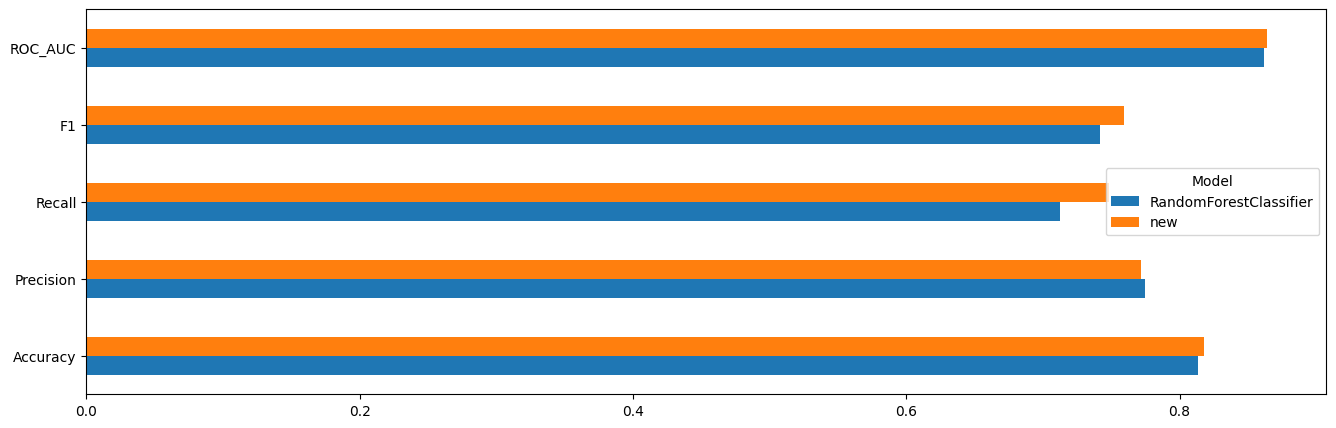

In [124]:
dff.drop('short_model', axis=1, inplace=True)
dff.set_index('Model', inplace=True)
dff.transpose().plot.barh(figsize=(16, 5))